In [1]:
# NBA Attendance Machine Learning Models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import xgboost as xgb
import shap

C1 = "#1D428A"
C2 = "#C8102E"
C3 = "#FDB927"
NEUTRAL = "#8C8C8C"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F9",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E5E5E5",
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load Data

import os
BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.makedirs(f"{BASE}/reports", exist_ok=True)

df = pd.read_csv(f"{BASE}/data/processed/nba_features.csv", parse_dates=["game_date"])
df = df.sort_values(["team", "season", "game_date"]).reset_index(drop=True)

print(f"Loaded {len(df):,} games x {df.shape[1]} features")
print(f"Teams: {df['team'].nunique()}, Seasons: {sorted(df['season'].unique())}")

# Model Variables
FEATURES = [
    "is_weekend",
    "day_num",
    "month_num",
    "days_into_season",
    "tier_numeric",
    "is_marquee",
    "win_streak",
    "loss_streak",
    "rolling_win_pct",
    "season_win_pct",
    "is_back_to_back",
    "is_bad_weather",
    "is_cold",
    "temp_avg_f",
]

# Regression and Classification Targets
TARGET_REG   = "attendance_pct"
TARGET_CLF   = "below_85pct"

# Drop rows with missing features
model_df = df[FEATURES + [TARGET_REG, TARGET_CLF, "team", "season", "game_date"]].dropna()
print(f"\nModel Dataset: {len(model_df):,} games after dropping nulls")
print(f"Missing Values Dropped: {len(df) - len(model_df)}")
print(f"\nClass Balance (Below 85% Capacity):")
print(model_df[TARGET_CLF].value_counts(normalize=True).round(3))

Loaded 3,705 games x 42 features
Teams: 30, Seasons: ['2022-23', '2023-24', '2024-25']

Model Dataset: 3,435 games after dropping nulls
Missing Values Dropped: 270

Class Balance (Below 85% Capacity):
below_85pct
0    0.924
1    0.076
Name: proportion, dtype: float64


In [3]:
# Model 1: What factors drive attendance variation?

X = model_df[FEATURES].copy()
y = model_df[TARGET_REG].copy()

# Fill remaining nulls with median
X = X.fillna(X.median())

# Predict league mean every game
baseline_pred = np.full(len(y), y.mean())
baseline_mae  = mean_absolute_error(y, baseline_pred)
print(f"Baseline Mean Absolute Error: {baseline_mae:.4f} ({baseline_mae*100:.2f}%)")

# Time Series Validation
# Sort by date
model_df_sorted = model_df.sort_values("game_date")
X_sorted = model_df_sorted[FEATURES].fillna(model_df_sorted[FEATURES].median())
y_sorted = model_df_sorted[TARGET_REG]

tscv = TimeSeriesSplit(n_splits=5)

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0,
)

cv_maes, cv_rmses, cv_r2s = [], [], []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_sorted)):
    X_train, X_test = X_sorted.iloc[train_idx], X_sorted.iloc[test_idx]
    y_train, y_test = y_sorted.iloc[train_idx], y_sorted.iloc[test_idx]

    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    preds = xgb_model.predict(X_test)

    cv_maes.append(mean_absolute_error(y_test, preds))
    cv_rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
    cv_r2s.append(r2_score(y_test, preds))

print(f"XGBoost Time Series Regression")
print(f"Mean Absolute Error:  {np.mean(cv_maes):.4f} ± {np.std(cv_maes):.4f}  ({np.mean(cv_maes)*100:.2f}% Average Error)")
print(f"Root Mean Squared Error: {np.mean(cv_rmses):.4f} ± {np.std(cv_rmses):.4f}")
print(f"R Squared:   {np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")
print(f"Improvement: {((baseline_mae - np.mean(cv_maes)) / baseline_mae * 100):.1f}%")

# Fit Final Model
xgb_model.fit(X_sorted, y_sorted, verbose=False)
print("\nFinal model trained on full dataset.")

Baseline Mean Absolute Error: 0.0515 (5.15%)
XGBoost Time Series Regression
Mean Absolute Error:  0.0506 ± 0.0069  (5.06% Average Error)
Root Mean Squared Error: 0.0681 ± 0.0081
R Squared:   -0.0280 ± 0.1511
Improvement: 1.8%

Final model trained on full dataset.


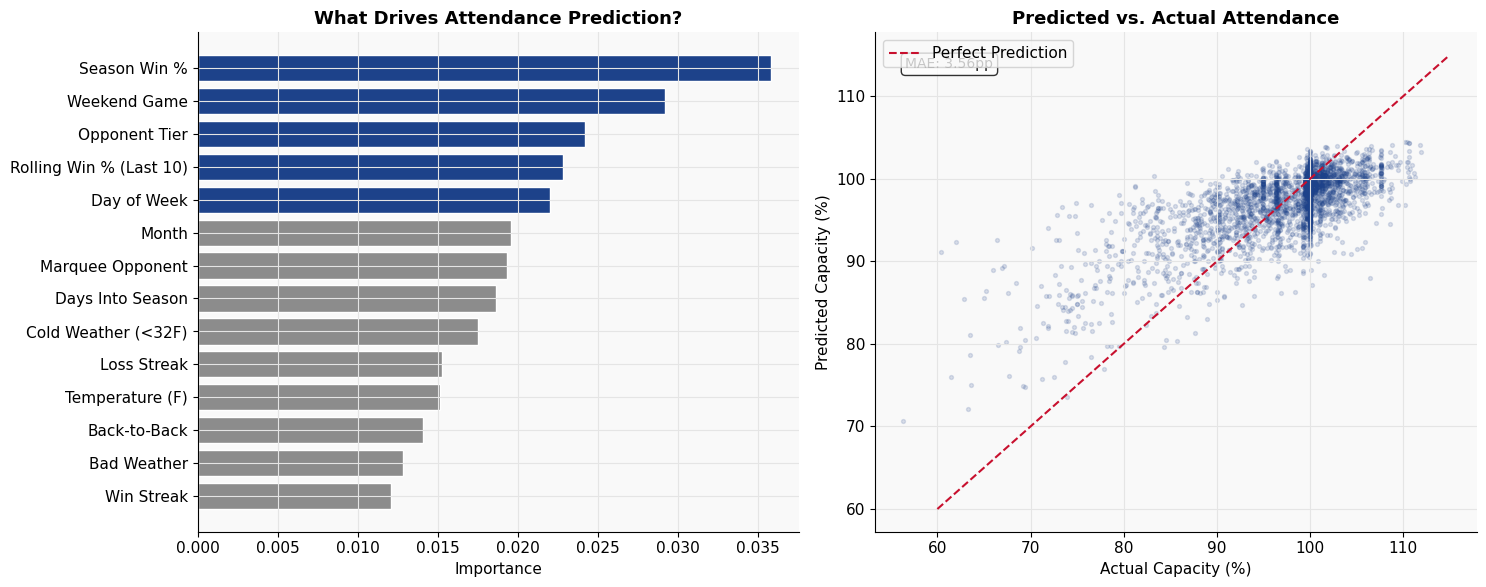

Top 5 Attendance Drivers
  Season Win %                   0.0358
  Weekend Game                   0.0292
  Opponent Tier                  0.0242
  Rolling Win % (Last 10)        0.0228
  Day of Week                    0.0220


In [4]:
# Feature Importance

importance_dict = xgb_model.get_booster().get_score(importance_type="gain")

feature_importance = pd.DataFrame({
    "feature":    list(importance_dict.keys()),
    "importance": list(importance_dict.values()),
}).sort_values("importance", ascending=False)

FEATURE_LABELS = {
    "tier_numeric":      "Opponent Tier",
    "is_weekend":        "Weekend Game",
    "win_streak":        "Win Streak",
    "rolling_win_pct":   "Rolling Win % (Last 10)",
    "season_win_pct":    "Season Win %",
    "days_into_season":  "Days Into Season",
    "month_num":         "Month",
    "day_num":           "Day of Week",
    "is_marquee":        "Marquee Opponent",
    "loss_streak":       "Loss Streak",
    "is_bad_weather":    "Bad Weather",
    "temp_avg_f":        "Temperature (F)",
    "is_back_to_back":   "Back-to-Back",
    "is_cold":           "Cold Weather (<32F)",
}
feature_importance["label"] = feature_importance["feature"].map(FEATURE_LABELS).fillna(feature_importance["feature"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = [C1 if i < 5 else NEUTRAL for i in range(len(feature_importance))]
axes[0].barh(feature_importance["label"], feature_importance["importance"],
             color=colors, edgecolor="white")
axes[0].set_xlabel("Importance")
axes[0].set_title("What Drives Attendance Prediction?")
axes[0].invert_yaxis()

y_pred_full = xgb_model.predict(X_sorted)
axes[1].scatter(y_sorted * 100, y_pred_full * 100,
                alpha=0.15, s=8, color=C1)
axes[1].plot([60, 115], [60, 115], color=C2, linewidth=1.5,
             linestyle="--", label="Perfect Prediction")
axes[1].set_xlabel("Actual Capacity (%)")
axes[1].set_ylabel("Predicted Capacity (%)")
axes[1].set_title("Predicted vs. Actual Attendance")
axes[1].legend()

overall_mae = mean_absolute_error(y_sorted, y_pred_full)
axes[1].text(0.05, 0.95, f"MAE: {overall_mae*100:.2f}pp",
             transform=axes[1].transAxes, fontsize=10, va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{BASE}/reports/07_xgboost_regression.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 Attendance Drivers")
for _, row in feature_importance.head(5).iterrows():
    print(f"  {row.label:<30} {row.importance:.4f}")

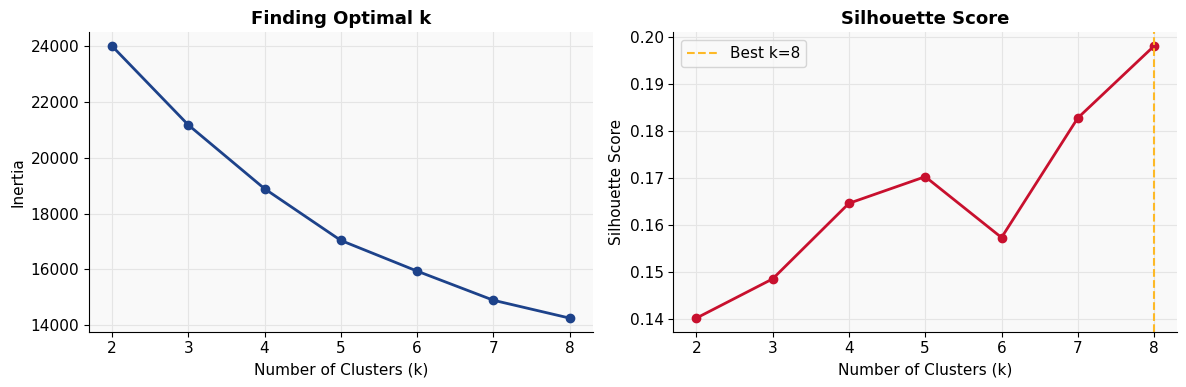

Optimal k by Silhouette: 8
Silhouette Scores: {2: 0.14, 3: 0.148, 4: 0.165, 5: 0.17, 6: 0.157, 7: 0.183, 8: 0.198}


In [5]:
# Model 2: Do NBA games cluster into demand tiers?

CLUSTER_FEATURES = [
    "attendance_pct",
    "tier_numeric",
    "is_weekend",
    "win_streak",
    "rolling_win_pct",
    "days_into_season",
    "is_back_to_back",
    "is_bad_weather",
]

cluster_df = model_df[CLUSTER_FEATURES].fillna(model_df[CLUSTER_FEATURES].median())

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# Find Optimal K
inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o", color=C1, linewidth=2)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Finding Optimal k")

axes[1].plot(list(k_range), silhouettes, marker="o", color=C2, linewidth=2)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")

best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color=C3, linewidth=1.5, linestyle="--",
                label=f"Best k={best_k}")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/reports/08_kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Optimal k by Silhouette: {best_k}")
print("Silhouette Scores:", {k: round(s, 3) for k, s in zip(k_range, silhouettes)})

=== Cluster Profiles ===
          label  n_games  avg_att_pct  avg_tier  pct_weekend  avg_win_streak  pct_b2b  pct_bad_wx
    High Demand      526        0.995     2.065        1.000           0.977    0.000       0.000
    High Demand      597        0.994     2.099        0.000           0.960    0.000       0.000
    High Demand      326        0.990     1.954        0.466           6.810    0.479       0.150
Moderate Demand      533        0.988     2.043        1.000           0.925    1.000       0.000
Moderate Demand      293        0.985     2.024        1.000           1.119    0.509       1.000
Moderate Demand      534        0.982     2.084        0.000           1.122    1.000       0.000
  Below Average      342        0.969     2.137        0.000           1.120    0.392       1.000
        At Risk      284        0.796     1.768        0.215           0.613    0.440       0.092


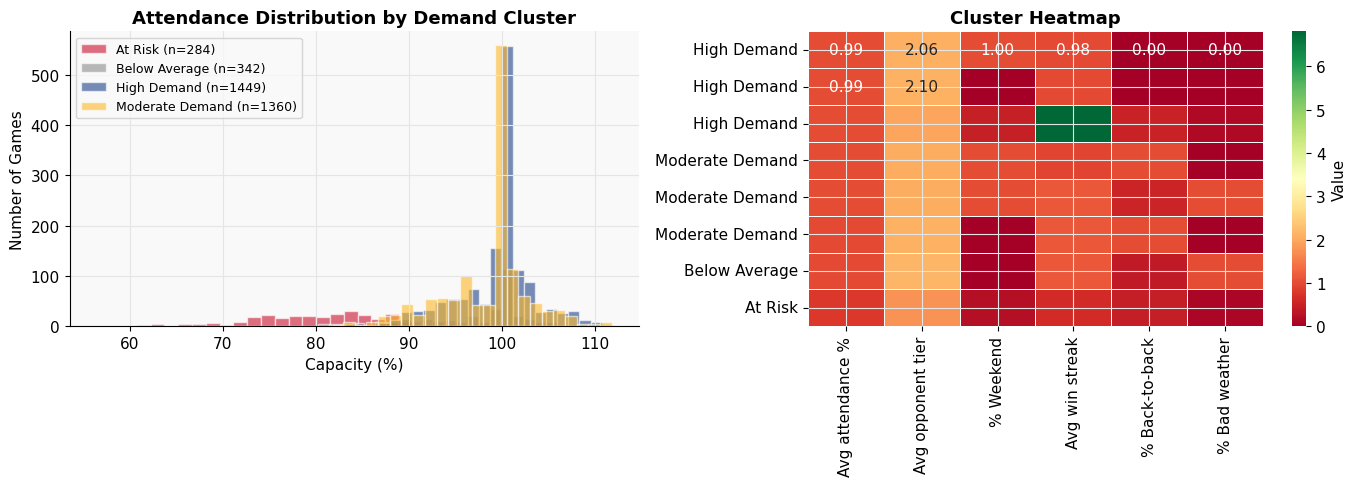

In [6]:
# Fit Final K-Means
FINAL_K = best_k

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
model_df = model_df.copy()
model_df["cluster"] = km_final.fit_predict(X_scaled)

# Profile Each Cluster
cluster_profile = (model_df.groupby("cluster")
    .agg(
        n_games        = ("game_id" if "game_id" in model_df.columns else "attendance_pct", "count"),
        avg_att_pct    = ("attendance_pct", "mean"),
        avg_tier       = ("tier_numeric", "mean"),
        pct_weekend    = ("is_weekend", "mean"),
        avg_win_streak = ("win_streak", "mean"),
        avg_roll_win   = ("rolling_win_pct", "mean"),
        pct_b2b        = ("is_back_to_back", "mean"),
        pct_bad_wx     = ("is_bad_weather", "mean"),
    )
    .round(3)
    .reset_index()
    .sort_values("avg_att_pct", ascending=False))

# Label Clusters Based on Profile
def label_cluster(row):
    if row.avg_att_pct >= 0.99:
        return "High Demand"
    elif row.avg_att_pct >= 0.97:
        return "Moderate Demand"
    elif row.avg_att_pct >= 0.94:
        return "Below Average"
    else:
        return "At Risk"

cluster_profile["label"] = cluster_profile.apply(label_cluster, axis=1)
cluster_map = dict(zip(cluster_profile["cluster"], cluster_profile["label"]))
model_df["cluster_label"] = model_df["cluster"].map(cluster_map)

print("=== Cluster Profiles ===")
display_cols = ["label","n_games","avg_att_pct","avg_tier",
                "pct_weekend","avg_win_streak","pct_b2b","pct_bad_wx"]
print(cluster_profile[display_cols].to_string(index=False))

# Visualize Clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_colors = {
    "High Demand":      C1,
    "Moderate Demand":  C3,
    "Below Average":    NEUTRAL,
    "At Risk":          C2,
}

# Attendance Distribution by Cluster
for label, grp in model_df.groupby("cluster_label"):
    axes[0].hist(grp["attendance_pct"] * 100, bins=25, alpha=0.6,
                 color=cluster_colors.get(label, NEUTRAL),
                 label=f"{label} (n={len(grp)})", edgecolor="white")
axes[0].set_xlabel("Capacity (%)")
axes[0].set_ylabel("Number of Games")
axes[0].set_title("Attendance Distribution by Demand Cluster")
axes[0].legend(fontsize=9)

# Cluster Heatmap
profile_heat = cluster_profile.set_index("label")[
    ["avg_att_pct","avg_tier","pct_weekend","avg_win_streak","pct_b2b","pct_bad_wx"]
].rename(columns={
    "avg_att_pct":    "Avg attendance %",
    "avg_tier":       "Avg opponent tier",
    "pct_weekend":    "% Weekend",
    "avg_win_streak": "Avg win streak",
    "pct_b2b":        "% Back-to-back",
    "pct_bad_wx":     "% Bad weather",
})

sns.heatmap(profile_heat, ax=axes[1], annot=True, fmt=".2f",
            cmap="RdYlGn", linewidths=0.5,
            cbar_kws={"label": "Value"})
axes[1].set_title("Cluster Heatmap")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(f"{BASE}/reports/09_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Model 3: Can we predict which games will fall below 85% capacity?

PRE_SEASON_FEATURES = [
    "is_weekend",
    "day_num",
    "month_num",
    "days_into_season",
    "tier_numeric",
    "is_marquee",
    "is_back_to_back",
]

X_clf = model_df[PRE_SEASON_FEATURES].fillna(0)
y_clf = model_df[TARGET_CLF]

print(f"Class Distribution:")
print(f"  Above 85% (0): {(y_clf==0).sum():,} ({(y_clf==0).mean():.1%})")
print(f"  Below 85% (1): {(y_clf==1).sum():,} ({(y_clf==1).mean():.1%})")
print(f"\nClass Imbalance Ratio: {(y_clf==0).sum() / (y_clf==1).sum():.1f}:1")

# Compare Models
model_df_sorted2 = model_df.sort_values("game_date")
X_clf_sorted = model_df_sorted2[PRE_SEASON_FEATURES].fillna(0)
y_clf_sorted  = model_df_sorted2[TARGET_CLF]

tscv = TimeSeriesSplit(n_splits=5)

results = {}
for name, clf in [
    ("Logistic Regression", LogisticRegression(class_weight="balanced",
                                                max_iter=1000, random_state=42)),
    ("XGBoost Classifier",  xgb.XGBClassifier(n_estimators=200, max_depth=4,
                                               learning_rate=0.05,
                                               scale_pos_weight=(y_clf==0).sum()/(y_clf==1).sum(),
                                               random_state=42, verbosity=0,
                                               eval_metric="logloss")),
]:
    aucs, f1s = [], []
    for train_idx, test_idx in tscv.split(X_clf_sorted):
        X_tr, X_te = X_clf_sorted.iloc[train_idx], X_clf_sorted.iloc[test_idx]
        y_tr, y_te = y_clf_sorted.iloc[train_idx], y_clf_sorted.iloc[test_idx]
        clf.fit(X_tr, y_tr)
        proba = clf.predict_proba(X_te)[:, 1]
        pred  = clf.predict(X_te)
        aucs.append(roc_auc_score(y_te, proba))
        from sklearn.metrics import f1_score
        f1s.append(f1_score(y_te, pred, zero_division=0))
    results[name] = {"AUC": np.mean(aucs), "F1": np.mean(f1s)}
    print(f"  {name:<25}  AUC: {np.mean(aucs):.3f}  F1: {np.mean(f1s):.3f}")

Class Distribution:
  Above 85% (0): 3,174 (92.4%)
  Below 85% (1): 261 (7.6%)

Class Imbalance Ratio: 12.2:1
  Logistic Regression        AUC: 0.637  F1: 0.112
  XGBoost Classifier         AUC: 0.567  F1: 0.139


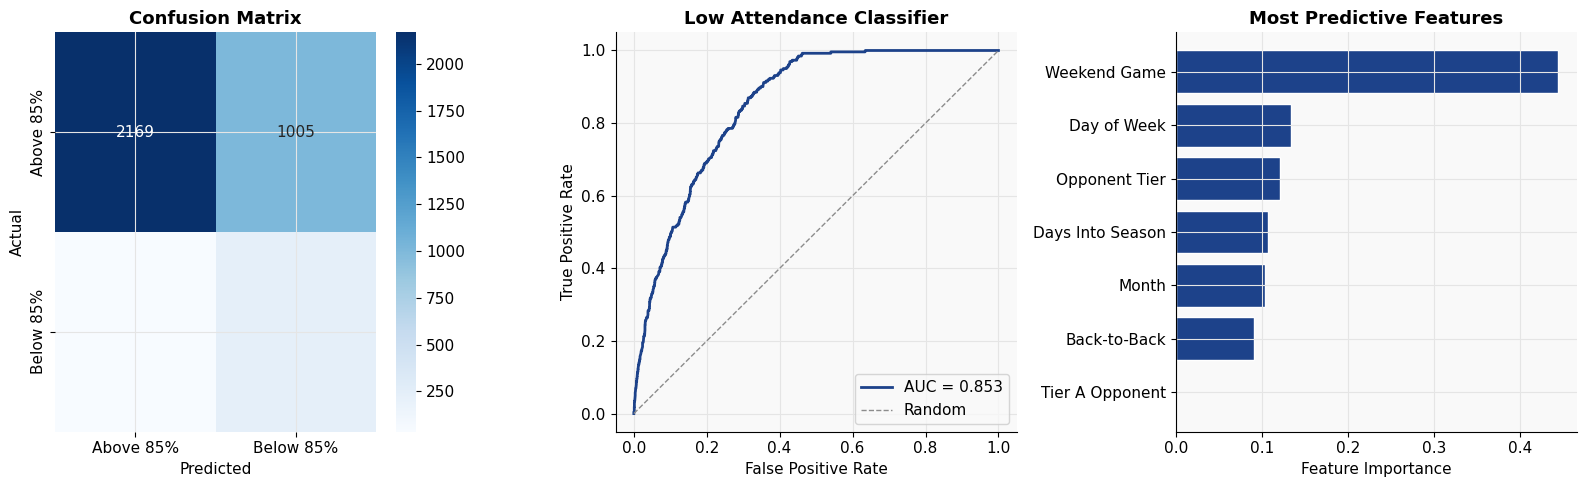

Classification Report
              precision    recall  f1-score   support

   Above 85%       0.98      0.68      0.81      3174
   Below 85%       0.18      0.87      0.30       261

    accuracy                           0.70      3435
   macro avg       0.58      0.78      0.56      3435
weighted avg       0.92      0.70      0.77      3435

ROC-AUC: 0.853


In [8]:
# Final Classifier
final_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=(y_clf==0).sum()/(y_clf==1).sum(),
    random_state=42, verbosity=0, eval_metric="logloss"
)
final_clf.fit(X_clf_sorted, y_clf_sorted)

y_pred_clf   = final_clf.predict(X_clf_sorted)
y_proba_clf  = final_clf.predict_proba(X_clf_sorted)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_clf_sorted, y_pred_clf)
sns.heatmap(cm, ax=axes[0], annot=True, fmt="d", cmap="Blues",
            xticklabels=["Above 85%","Below 85%"],
            yticklabels=["Above 85%","Below 85%"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
fpr, tpr, _ = roc_curve(y_clf_sorted, y_proba_clf)
auc_score = roc_auc_score(y_clf_sorted, y_proba_clf)
axes[1].plot(fpr, tpr, color=C1, linewidth=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0,1],[0,1], color=NEUTRAL, linewidth=1, linestyle="--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Low Attendance Classifier")
axes[1].legend()

# Feature Importance
feat_imp = pd.DataFrame({
    "feature": PRE_SEASON_FEATURES,
    "importance": final_clf.feature_importances_,
}).sort_values("importance", ascending=False)

feat_labels = {
    "tier_numeric":     "Opponent Tier",
    "is_weekend":       "Weekend Game",
    "day_num":          "Day of Week",
    "month_num":        "Month",
    "days_into_season": "Days Into Season",
    "is_marquee":       "Tier A Opponent",
    "is_back_to_back":  "Back-to-Back",
}
feat_imp["label"] = feat_imp["feature"].map(feat_labels)

axes[2].barh(feat_imp["label"], feat_imp["importance"],
             color=C1, edgecolor="white")
axes[2].set_xlabel("Feature Importance")
axes[2].set_title("Most Predictive Features")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{BASE}/reports/10_classifier.png", dpi=150, bbox_inches="tight")
plt.show()

print("Classification Report")
print(classification_report(y_clf_sorted, y_pred_clf,
      target_names=["Above 85%","Below 85%"]))
print(f"ROC-AUC: {auc_score:.3f}")

In [9]:
# Risk Score Every Game
model_df["at_risk_prob"] = final_clf.predict_proba(X_clf_sorted)[:, 1]

# Join Columns
context_cols = ["team","season","game_date","opponent","day_of_week",
                "opponent_tier","is_back_to_back","attendance_pct"]

high_risk = (model_df.join(df[context_cols].loc[model_df.index], rsuffix="_ctx")
             .sort_values("at_risk_prob", ascending=False)
             [context_cols + ["at_risk_prob"]]
             .head(20))

print("Top 20 Highest-Risk Games")
print(high_risk.to_string(index=False))

print("""
NOTE: Several flagged games show actual attendance above 100% capacity.
The classifier cannot account for franchise specific sellout behavior.
Best for mid-tier franchises — Brooklyn, Atlanta, LA Clippers, Memphis.
""")

# Summary
flagged = model_df[model_df["at_risk_prob"] > 0.5]
print(f"Games with >50% predicted risk: {len(flagged):,} ({len(flagged)/len(model_df):.1%})")
print("\nTop teams by flagged games:")
print(df.loc[flagged.index, "team"].value_counts().head(10).to_string())

Top 20 Highest-Risk Games
                 team  season  game_date               opponent day_of_week opponent_tier  is_back_to_back  attendance_pct  at_risk_prob
        Atlanta Hawks 2022-23 2022-12-28          Brooklyn Nets   Wednesday             B                0          1.0861      0.844905
      Houston Rockets 2023-24 2024-01-20              Utah Jazz    Saturday             C                0          0.9204      0.821637
Oklahoma City Thunder 2023-24 2024-02-04        Toronto Raptors      Sunday             B                1          0.9372      0.821637
        Atlanta Hawks 2023-24 2024-02-10        Houston Rockets    Saturday             C                0          1.0544      0.821637
 Los Angeles Clippers 2024-25 2024-12-03 Portland Trail Blazers     Tuesday             C                1          0.8657      0.813544
        Brooklyn Nets 2024-25 2025-03-10     Los Angeles Lakers      Monday             A                0          1.0272      0.813544
     Dallas Mav